In [1]:
import matplotlib.pyplot as plt
import numpy as np
#%matplotlib widget
%matplotlib inline

# Guass elimination function

In [2]:
def show(A,fmt='%+7.2f'):
    """
    Function to more neatly print out the matrix.
    """
    print('--')
    for i, As in enumerate(A):
        cr=''
        for j, a in enumerate(As):
            cr=f'{cr} {fmt}'%a
        print(cr)

import numpy as np


def gauss(A):
    """
    Gauss elimination

    Arguments
    --------
    A: augmented matrix in  [n,n+1] dimension

    Returns
    -------
    Root in [n]-dimensional vector.
    """
    # swap and forward
    for icol in range(0,A.shape[0]-1):
        ## swap
        a=np.abs(A[icol:,icol])
        ind=np.argsort(a)
        ind=ind[::-1] # reverse order
        A[icol:,:]=A[icol:,:][ind,:]

        ## forward
        for irow in range(icol+1,A.shape[0]):
            A[irow,:]=A[irow,:]-A[irow,icol]/A[icol,icol]*A[icol,:]
    # now one could 'diagonalize'
    for icol in range(A.shape[0]-1,0,-1):
        for irow in range(0,icol):
            f=A[irow,icol]/A[icol,icol]
            A[irow,:]=A[irow,:]-f*A[icol,:]
    for icol in range(A.shape[0]):
        A[icol,:]=A[icol,:]/A[icol,icol]
    return A[:,-1]

# initial empty A.
A=np.zeros((3,4))
# filling up the matrix.
A[0,:]=2,3,3,9
A[1,:]=1,-1,1,1
A[2,:]=3,11,5,35
gauss(A)

array([ 21. ,   4.5, -15.5])

# Example 1 

$$
x^2+y^2=7
\newline
e^x+y=8
$$

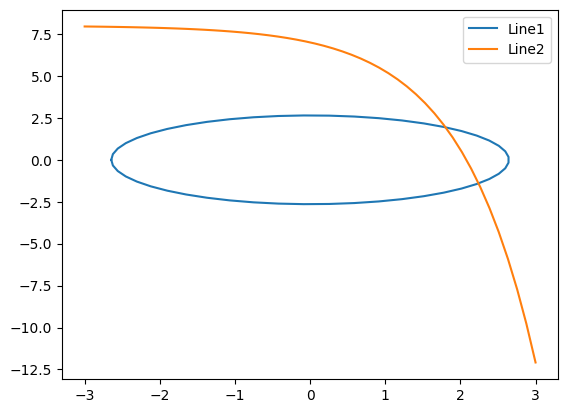

In [3]:
## 1st line
ths=np.linspace(-np.pi,np.pi)
r=np.sqrt(7)
x=np.cos(ths)*r
y=np.sin(ths)*r
plt.plot(x,y,label='Line1')
## 2nd line
x=np.linspace(-3,3)
y=8-np.exp(x)
plt.plot(x,y,label='Line2')
plt.legend()
#plt.gca().set_aspect('equal')

## Example 1 solution

In [4]:
## Canvas

## 1st line
ths=np.linspace(-np.pi,np.pi)
r=np.sqrt(7)
x=np.cos(ths)*r
y=np.sin(ths)*r

## 2nd line
x=np.linspace(-3,3)
y=8-np.exp(x)

## Function and Jacobian required for NR procedure
def func(x1,x2):
    f=np.zeros(2) #
    f[0]=x1**2+x2**2-7
    f[1]=np.exp(x1)+x2-8
    return f
def jacob(x1,x2):
    j=np.zeros((2,2)) # 2x2 jacob
    j[0,0]=2*x1
    j[0,1]=2*x2
    j[1,0]=np.exp(x1)
    j[1,1]=1
    return j

## NEWTON-RAPHSON begins here.
# hist arrays for recording changes.
## Initial guess
x=np.zeros(2) ## initial guess
x[::]=-1.0 ## initial guess

# Tolerance setting
tol=1e-9
err=tol*2
#
n=0
while err>tol and n<50:
    # jacobian and functions
    J=jacob(*x)
    F=func(*x)

    # Create augmented matrix A
    A=np.zeros((J.shape[0],J.shape[0]+1))
    A[:2,:2]=J[:,:]
    A[:,-1]=-F[::]

    # Obtain Delta x via guass elimination method
    dx=gauss(A)

    # Update x
    x=x+dx
    n+=1

    # estimate the error
    err=np.sqrt((F**2).sum())

print('solution:',x)

solution: [ 2.2413324  -1.40585528]


## Example 1 solution with Figures

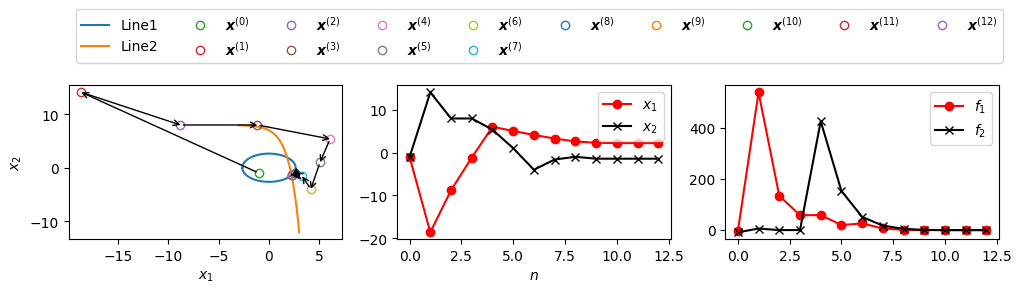

In [5]:
## Canvas
fig=plt.figure(figsize=(12,2))
ax1=fig.add_subplot(131)
ax2=fig.add_subplot(132)
ax3=fig.add_subplot(133)

## 1st line
ths=np.linspace(-np.pi,np.pi)
r=np.sqrt(7)
x=np.cos(ths)*r
y=np.sin(ths)*r
ax1.plot(x,y,label='Line1')

## 2nd line
x=np.linspace(-3,3)
y=8-np.exp(x)
ax1.plot(x,y,label='Line2')

## Function and Jacobian required for NR procedure
def func(x1,x2):
    f=np.zeros(2) #
    f[0]=x1**2+x2**2-7
    f[1]=np.exp(x1)+x2-8
    return f
def jacob(x1,x2):
    j=np.zeros((2,2)) # 2x2 jacob
    j[0,0]=2*x1
    j[0,1]=2*x2
    j[1,0]=np.exp(x1)
    j[1,1]=1
    return j

## NEWTON-RAPHSON begins here.
# hist arrays for recording changes.
hist=[]
fhist=[]
## Initial guess
x=np.zeros(2) ## initial guess
x[::]=-1.0 ## initial guess

# Tolerance setting
tol=1e-9
err=tol*2
#
n=0
while err>tol and n<50:
    # plotting the trajectory of vector x.
    ax1.plot(*x,'o',mfc='None',label=r'$\boldsymbol{x}^{(%i)}$'%n)

    # jacobian and functions
    J=jacob(*x)
    F=func(*x)

    # history
    hist.append(x)
    fhist.append(F)

    # Create augmented matrix A
    A=np.zeros((J.shape[0],J.shape[0]+1))
    A[:2,:2]=J[:,:]
    A[:,-1]=-F[::]

    # Obtain Delta x via guass elimination method
    dx=gauss(A)

    #
    ax1.annotate( "", xy=x, xytext=x+dx,
              arrowprops=dict( arrowstyle="<-",shrinkA=0 ) )
    mid=np.array(x)+np.array(dx)/2.
    x=x+dx
    n+=1
    err=np.sqrt((F**2).sum())

hist=np.array(hist)
fhist=np.array(fhist)

ax1.legend(loc='lower left',bbox_to_anchor=(0,1.1),ncols=10)
ax1.set_xlabel(r'$x_1$')
ax1.set_ylabel(r'$x_2$')
ax2.plot(hist[:,0],'-ro',label=r'$x_1$')
ax2.plot(hist[:,1],'-kx',label=r'$x_2$')
ax3.plot(fhist[:,0],'-ro',label=r'$f_1$')
ax3.plot(fhist[:,1],'-kx',label=r'$f_2$')
ax2.set_xlabel(r'$n$')
for i, ax in enumerate(fig.axes[1:]):
    ax.legend()
## guass elimination


# Example 2

$$
xy=10
\newline
x^2-y=3
$$

NR 적용위해 함수 형태로 표현하면
$$
f_1(x,y)=xy-10
\newline
f_2(x,y)=x^2-y-3
$$

line1
$$
y=10/x
$$

Line 2
$$
y=x^2-3
$$

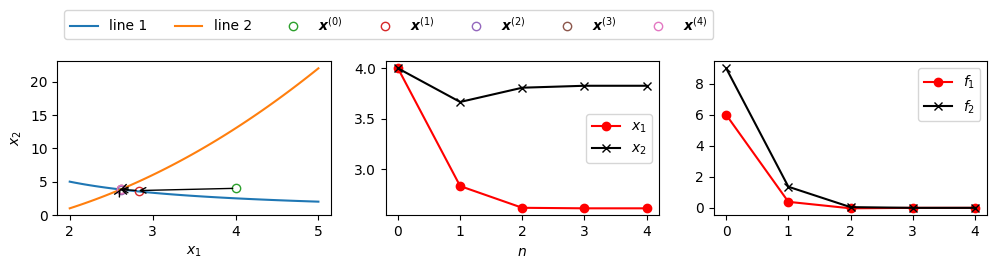

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f1(x,y):  return x*y-10
def f2(x,y):  return x**2-y-3
def func(x,y): return np.array([f1(x,y),f2(x,y)])

def jacob(x,y):
    j=np.zeros((2,2))
    j[0,0]=y
    j[0,1]=x
    j[1,0]=2*x
    j[1,1]=-1
    return j

xs=np.linspace(2,5)

## Canvas
fig=plt.figure(figsize=(12,2))
ax1=fig.add_subplot(131)
ax2=fig.add_subplot(132)
ax3=fig.add_subplot(133)

## line 1
ax1.plot(xs,10/xs,label='line 1')
## line 2
ax1.plot(xs,xs**2-3,label='line 2')
ax1.legend()


## NEWTON-RAPHSON begins here.
# hist arrays for recording changes.
hist=[]
fhist=[]
## Initial guess
x=np.zeros(2) ## initial guess
x[::]=4.0 ## initial guess

# Tolerance setting
tol=1e-9
err=tol*2
#
n=0
while err>tol and n<50:
    # plotting the trajectory of vector x.
    ax1.plot(*x,'o',mfc='None',label=r'$\boldsymbol{x}^{(%i)}$'%n)

    # jacobian and functions
    J=jacob(*x)
    F=func(*x)

    # history
    hist.append(x)
    fhist.append(F)

    # Create augmented matrix A
    A=np.zeros((J.shape[0],J.shape[0]+1))
    A[:2,:2]=J[:,:]
    A[:,-1]=-F[::]

    # Obtain Delta x via guass elimination method
    dx=gauss(A)

    #
    ax1.annotate( "", xy=x, xytext=x+dx,
              arrowprops=dict( arrowstyle="<-",shrinkA=0 ) )
    mid=np.array(x)+np.array(dx)/2.
    x=x+dx
    n+=1
    err=np.sqrt((F**2).sum())

hist=np.array(hist)
fhist=np.array(fhist)

ax1.legend(loc='lower left',bbox_to_anchor=(0,1.1),ncols=10)
ax1.set_xlabel(r'$x_1$')
ax1.set_ylabel(r'$x_2$')
ax2.plot(hist[:,0],'-ro',label=r'$x_1$')
ax2.plot(hist[:,1],'-kx',label=r'$x_2$')
ax3.plot(fhist[:,0],'-ro',label=r'$f_1$')
ax3.plot(fhist[:,1],'-kx',label=r'$f_2$')
ax2.set_xlabel(r'$n$')
for i, ax in enumerate(fig.axes[1:]):
    ax.legend()
## guass elimination

Example 2 - Modulize NR

In [137]:
import numpy as np
import matplotlib.pyplot as plt

def gauss(A):
    """
    Gauss elimination

    Arguments
    --------
    A: augmented matrix in  [n,n+1] dimension

    Returns
    -------
    Root in [n]-dimensional vector.
    """
    # swap and forward
    for icol in range(0,A.shape[0]-1):
        ## swap
        a=np.abs(A[icol:,icol])
        ind=np.argsort(a)
        ind=ind[::-1] # reverse order
        A[icol:,:]=A[icol:,:][ind,:]

        ## forward
        for irow in range(icol+1,A.shape[0]):
            A[irow,:]=A[irow,:]-A[irow,icol]/A[icol,icol]*A[icol,:]
    # now one could 'diagonalize'
    for icol in range(A.shape[0]-1,0,-1):
        for irow in range(0,icol):
            f=A[irow,icol]/A[icol,icol]
            A[irow,:]=A[irow,:]-f*A[icol,:]
    for icol in range(A.shape[0]):
        A[icol,:]=A[icol,:]/A[icol,icol]
    return A[:,-1]

def mvNR(func,func_jac,xinit,mxiter=50,tol=1e-9):
    """
    Arguments
    ---------
    func: objective function
    func_jac: jacobian
    xinit: initial guess on x vectors.
    mxiter: (default is 50)
    tol.  : tolerance is 1e-9

    Returns
    -------
    x     : solution vector
    hist  : trajectory of x vector
    fhist : trajectory of f vector
    jhist : trajectory of jacobian matrix
    n     : number of iterations used
    """
    x=xinit[::]
    # hist arrays for recording changes.
    hist=[]
    fhist=[]
    jhist=[]
    # Tolerance setting
    err=tol*2
    n=0
    while err>tol and n<mxiter:
        # jacobian and functions
        J=jacob(*x)
        F=func(*x)

        # history
        hist.append(x)
        fhist.append(F)
        jhist.append(J)

        # Create augmented matrix A
        A=np.zeros((J.shape[0],J.shape[0]+1))
        A[:2,:2]=J[:,:]
        A[:,-1]=-F[::]

        # Obtain Delta x via guass elimination method
        dx=gauss(A)

        # updates x, count (n), and error
        x=x+dx
        n+=1
        err=np.sqrt((F**2).sum())

    ## Convert list to numpy arrays.
    hist=np.array(hist)
    fhist=np.array(fhist)
    jhist=np.array(jhist)
    return x,hist,fhist,jhist,n

# NR as simple as it gets

In [133]:
def f1(x,y):  return x*y-10
def f2(x,y):  return x**2-y-3
def func(x,y): return np.array([f1(x,y),f2(x,y)])
def jacob(x,y):
    j=np.zeros((2,2))
    j[0,0]=y
    j[0,1]=x
    j[1,0]=2*x
    j[1,1]=-1
    return j

## NEWTON-RAPHSON begins here.
## Initial guess
x=np.zeros(2) ## initial guess
x[::]=4.0 ## initial guess
x,hist,fhist,jhist,n=mvNR(func,jacob,xinit=np.ones(2),mxiter=50,tol=1e-5)
print(n)

6


## NR Geometric interpretation

- Separate function to create figures

In [176]:
def init_fig(f1,f2):
    fig=plt.figure(figsize=(8,8))
    ax1=fig.add_subplot(221)#,projection='3d')
    ax2=fig.add_subplot(222,projection='3d')
    ax3=fig.add_subplot(223)#,projection='3d')
    ax4=fig.add_subplot(224,projection='3d')

    # Grid
    x=np.linspace(-10,10,100)
    y=np.linspace(-10,10,100)
    X,Y=np.meshgrid(x,y)

    ## 2D contour plot
    mappable=ax1.contourf(X,Y,f1(X,Y),cmap='jet')
    plt.colorbar(mappable,ax=ax1,label=r'$f_1$')
    ax1.set_title(r'$f_1(x_1,x_2)$')
    ax1.set_xlabel(r'$x_1$')
    ax1.set_ylabel(r'$x_2$')
    ## 3D plane
    ax2.plot_surface(X,Y,f1(X,Y),cmap='jet')
    ax2.set_zlabel(r'$f_1$')
    ax2.set_xlabel(r'$x_1$')
    ax2.set_ylabel(r'$x_2$')

    ## 2D contour plot
    mappable=ax3.contourf(X,Y,f2(X,Y),cmap='jet')
    plt.colorbar(mappable,ax=ax3,label=r'$f_2$')
    ax3.set_title(r'$f_2(x_1,x_2)$')
    ax3.set_xlabel(r'$x_1$')
    ax3.set_ylabel(r'$x_2$')
    ## 3D plane
    ax4.plot_surface(X,Y,f2(X,Y),cmap='jet')
    ax4.set_zlabel(r'$f_2$')
    ax4.set_xlabel(r'$x_1$')
    ax4.set_ylabel(r'$x_2$')
    return fig,ax1,ax2,ax3,ax4

niters: 7


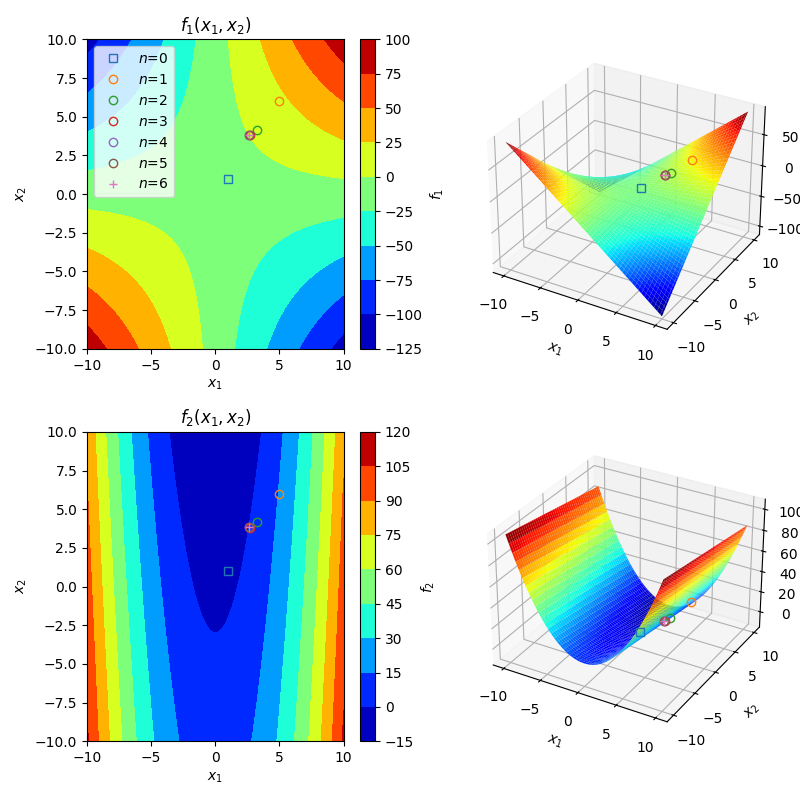

In [204]:
def f1(x,y):  return x*y-10
def f2(x,y):  return x**2-y-3
def func(x,y): return np.array([f1(x,y),f2(x,y)])
def jacob(x,y):
    j=np.zeros((2,2))
    j[0,0]=y
    j[0,1]=x
    j[1,0]=2*x
    j[1,1]=-1
    return j

## NEWTON-RAPHSON begins here.
## Initial guess
x=np.zeros(2) ## initial guess
x[::]=4.0 ## initial guess
x,hist,fhist,jhist,niters=mvNR(func,jacob,xinit=np.ones(2))
print(f'niters: {niters}')

## Below is to
%matplotlib widget
#%matplotlib inline

fig,ax1,ax2,ax3,ax4=init_fig(f1,f2)
fig.tight_layout()
fig.savefig(f'/tmp/%5.5i.png'%0)

kws=dict(mfc='None',zorder=100,ls='None')
for n,x in enumerate(hist):
    f1,f2=fhist[n]
    x1,x2=x
    jij=jhist[n]
    j11,j12=jij[0,:]
    j21,j22=jij[1,:]

    j11**2
    #ax1.plot([x1,x1*j11],[x2,x2*j12])

    kws.update(label=r'$n$=%i'%n)
    if n==0: kws.update(marker='s')
    elif n==len(hist)-1: kws.update(marker='+')
    else: kws.update(marker='o')
    ax1.plot(x1,x2,**kws)
    ax3.plot(x1,x2,**kws)
    ax2.plot(x1,x2,f1,**kws)
    ax4.plot(x1,x2,f2,**kws)
    ax1.legend(loc='upper left')
    fig.savefig(f'/tmp/%5.5i.png'%(n+1))

In [207]:
!rm -f /tmp/*.png

In [208]:
from glob import glob
fns='/tmp/*.png'
fns=glob(fns)

print(fns)
#ffmpeg

[]


In [209]:
import os, subprocess
default_ffmpeg=os.popen('which ffmpeg').read().split('\n')[0]
dst='/tmp'
fnout='mine.mp4'
!rm -f {fnout}
cmd=[default_ffmpeg,'-y','-r','1','-f','image2','-i',
        os.path.join(dst,'%05d.png').replace('\\','/'),
        '-vcodec',
        'libx264', '-crf', '25', '-vf', "pad=ceil(iw/2)*2:ceil(ih/2)*2",
        '-pix_fmt','yuv420p',fnout]
p=subprocess.Popen(cmd,stdout=subprocess.PIPE,stderr=subprocess.PIPE)
stdo,stde=p.communicate()
print(stdo.decode())
print(stde.decode())

!open {fnout}

!ffmpeg -y -i mine.mp4 mine.gif
!mv mine.gif ../data/mvNR.gif


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/7.1.1_3 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex -

In [210]:
ls ../data/

mvNR.gif
